# Day 1 — Data Quality Check
## SNB Customer Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['axes.unicode_minus'] = False
customers    = pd.read_csv('../Data/raw/snb_customers.csv', parse_dates=['join_date'])
transactions = pd.read_csv('../Data/raw/snb_transactions.csv', parse_dates=['date'])

print('Data loaded successfully')
print(f'  Customers:    {len(customers):,}')
print(f'  Transactions: {len(transactions):,}')

Data loaded successfully
  Customers:    5,000
  Transactions: 73,522


## 1 — Data Structure & Column Types

In [2]:
print('=== Customers ===')
print(customers.info())
print()
print('=== Transactions ===')
print(transactions.info())

=== Customers ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   5000 non-null   object        
 1   region        5000 non-null   object        
 2   segment       5000 non-null   object        
 3   join_date     5000 non-null   datetime64[ns]
 4   age           5000 non-null   int64         
 5   credit_score  5000 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 234.5+ KB
None

=== Transactions ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73522 entries, 0 to 73521
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  73522 non-null  object        
 1   customer_id     73522 non-null  object        
 2   date            73522 non-null  datetime64[ns]
 3   type 

## 2 — Missing Values & Duplicates

In [3]:
print('=== Missing Values — Customers ===')
missing_c = customers.isnull().sum()
print(missing_c[missing_c > 0] if missing_c.sum() > 0 else 'No missing values ✓')

print()
print('=== Missing Values — Transactions ===')
missing_t = transactions.isnull().sum()
print(missing_t[missing_t > 0] if missing_t.sum() > 0 else 'No missing values ✓')

print()
print('=== Duplicates ===')
print(f'Duplicate customers:    {customers.duplicated().sum()}')
print(f'Duplicate transactions: {transactions.duplicated().sum()}')

print()
print('=== Logical Checks ===')
print(f'Customers age < 18:     {(customers["age"] < 18).sum()}')
print(f'Customers age > 100:    {(customers["age"] > 100).sum()}')
print(f'Negative amounts:       {(transactions["amount"] < 0).sum()}')

=== Missing Values — Customers ===
No missing values ✓

=== Missing Values — Transactions ===
No missing values ✓

=== Duplicates ===
Duplicate customers:    0
Duplicate transactions: 0

=== Logical Checks ===
Customers age < 18:     0
Customers age > 100:    0
Negative amounts:       0


## 3 — Descriptive Statistics

In [4]:
print('=== Customers Stats ===')
display(customers.describe())

print('\n=== Transactions Stats ===')
display(transactions.describe())

=== Customers Stats ===


,join_date,age,credit_score
count,5000,5000.000000,5000.000000
mean,2024-06-29 01:17:28.319999744,43.509400,602.167600
min,2023-01-02 00:00:00,18.000000,300.000000
25%,2023-10-04 00:00:00,31.000000,450.000000
50%,2024-06-27 12:00:00,43.000000,601.000000
75%,2025-03-30 00:00:00,57.000000,754.000000
max,2026-01-01 00:00:00,69.000000,899.000000
std,NaN,15.072616,174.819074



=== Transactions Stats ===


,date,amount
count,73522,73522.00000
mean,2026-07-01 05:39:34.897309696,35988.11751
min,2026-01-01 00:00:00,50.79000
25%,2026-04-01 00:00:00,6311.76250
50%,2026-07-01 00:00:00,12315.52000
75%,2026-09-30 00:00:00,40937.00500
max,2026-12-31 00:00:00,199997.02000
std,NaN,50015.07589


## 4 — Customer Distribution Charts

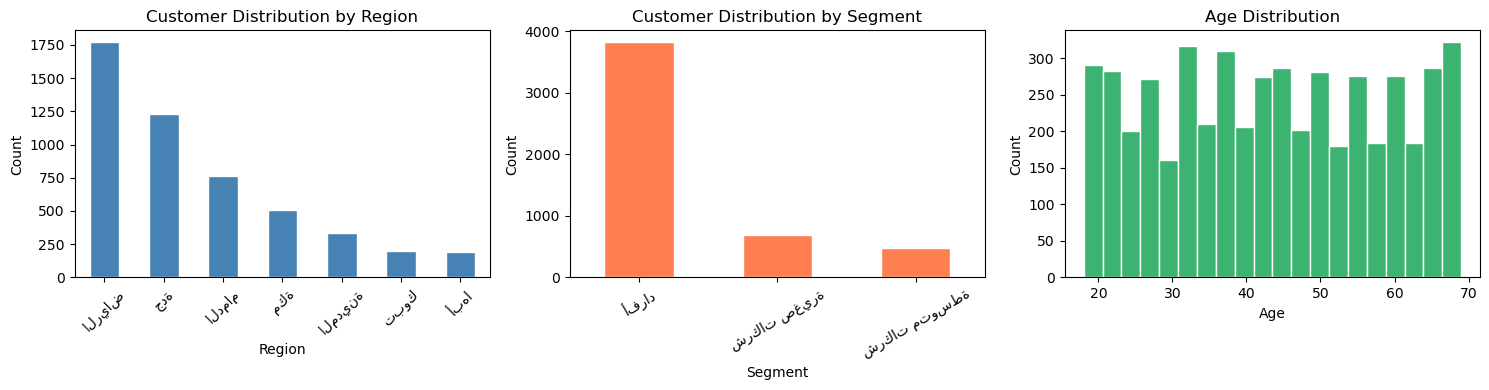

In [ ]:
import os

os.makedirs('../Outputs/chart', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Region Distribution
customers['region'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Customer Distribution by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Segment Distribution
customers['segment'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Customer Distribution by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

# Age Distribution
axes[2].hist(customers['age'], bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../Outputs/chart/01_customer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 — Monthly Transactions Chart

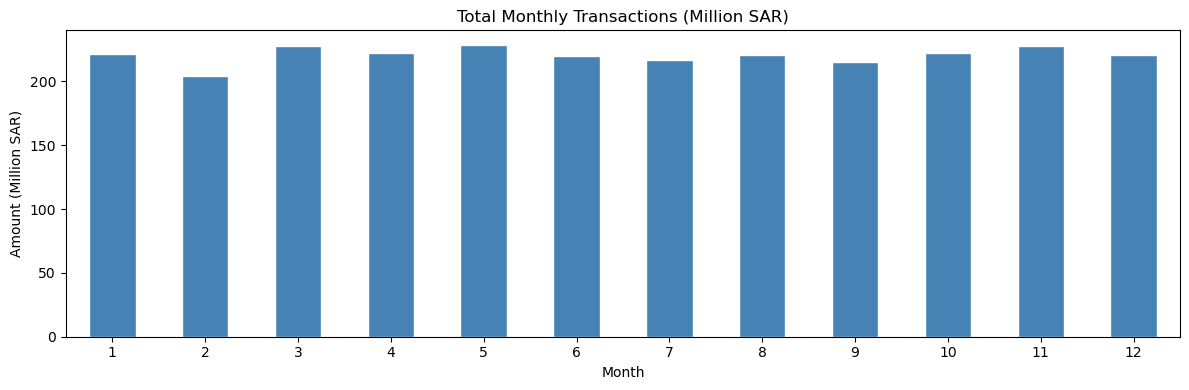

In [10]:
transactions['month'] = transactions['date'].dt.month
monthly = transactions.groupby('month')['amount'].sum() / 1_000_000

plt.figure(figsize=(12, 4))
monthly.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Monthly Transactions (Million SAR)')
plt.xlabel('Month')
plt.ylabel('Amount (Million SAR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../Outputs/chart/01_monthly_transactions.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 — Save Clean Data

In [9]:
os.makedirs('../Data/clean', exist_ok=True)

customers.to_csv('../Data/clean/snb_customers_clean.csv', index=False, encoding='utf-8-sig')
transactions.to_csv('../Data/clean/snb_transactions_clean.csv', index=False, encoding='utf-8-sig')

print('Clean data saved successfully')


Clean data saved successfully
